| ID  | Pergunta de Pesquisa                                                                                                                                                | Alternativas de Resposta (como será respondida)                                                                      | Dificuldade (1–10) |
| --- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------- | -------------------------------------------------------------------------------------------------------------------- | ------------------ |
| QP1 | Qual ferramenta de map matching apresenta maior acurácia no paradigma online sob diferentes taxas de amostragem das trajetórias?                                    | Comparação de métricas de acurácia agregadas por ferramenta e taxa de amostragem, com análise estatística descritiva | **4**              |
| QP2 | Qual ferramenta apresenta maior eficiência temporal no processamento online de trajetórias, considerando métricas de latência e variabilidade temporal (p95 e p99)? | Análise de latência média, p95 e p99 por ferramenta, com comparação direta entre distribuições                       | **3**              |
| QP3 | Qual ferramenta apresenta maior eficiência computacional, considerando a relação entre acurácia obtida e custo computacional (uso de CPU e memória)?                | Construção de métricas compostas ou análise pareada entre acurácia e consumo médio de CPU e memória                  | **6**              |
| QP4 | Qual ferramenta apresenta maior capacidade de processamento contínuo ao lidar com trajetórias longas e diferentes taxas de amostragem no paradigma online?          | Avaliação de throughput (pontos/s, km/s ou trajetórias/s) em cenários com trajetórias longas                         | **5**              |
| QP5 | Qual é o impacto do uso de processamento em lotes na acurácia e no desempenho computacional das ferramentas avaliadas?                                              | Comparação direta entre cenários com e sem batch, analisando diferenças relativas nas métricas                       | **4**              |


## Respostas

**QP1.** Melhor acurácia no online por taxa de amostragem (média de `accuracy` por ferramenta):

- sr=1.0: **barefoot** (0.9312)
- sr=5.0: **barefoot** (0.9777)
- sr=10.0: **barefoot** (0.9710)
- sr=20.0: **barefoot** (0.9548)

**QP2.** Eficiência temporal no online (média de latência por ferramenta):

- **barefoot**: p95=306.05 ms, p99=308.05 ms, média=283.35 ms
- graphium: p95=5456.12 ms, p99=5700.10 ms, média=4671.13 ms

Resposta: **barefoot** apresenta a menor latência e variabilidade (p95/p99).

**QP3.** Eficiência computacional (online), usando métrica composta `accuracy / (cpu_avg * mem_avg_mb)`:

- **barefoot**: 0.03126
- graphium: 0.00050

Resposta: **barefoot** tem a melhor relação acurácia/custo computacional.

**QP4.** Throughput (online) por taxa de amostragem (média de `e2e_throughput_pps`):

- sr=1.0: **graphium** (32.60 pts/s)
- sr=5.0: **graphium** (13.70 pts/s)
- sr=10.0: **graphium** (29.61 pts/s)
- sr=20.0: **barefoot** (1.64 pts/s)

Resposta: **graphium** domina em 1.0, 5.0 e 10.0; **barefoot** aparece como melhor em 20.0.

**QP5.** Impacto de batch vs non-batch (médias globais):

- batch: accuracy=0.8132, cpu_avg=0.534, mem_avg=599.33 MB, p95=4041.30 ms
- non-batch: accuracy=0.9587, cpu_avg=0.253, mem_avg=189.89 MB, p95=306.05 ms

Resposta: o uso de batch **reduz acurácia** e **piora desempenho** (maior CPU/memória e p95) nos dados agregados.


## Setup


In [2]:
from pathlib import Path
import re

import colorsys
import duckdb
import pandas as pd
import numpy as np
import matplotlib.colors as mc
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


import seaborn as sns
import plotly.express as px


In [3]:
color = {
    "barefoot": "tab:blue",
    "graphhopper": "tab:orange",
    "graphium (cold)": "tab:green",
    "graphium (warm)": "darkgreen",
    "osrm": "tab:red",
}

# Optional: enforce consistent plotting order
PLOT_ORDER = ["barefoot", "graphhopper", "graphium (cold)", "graphium (warm)", "osrm"]

In [4]:
RESULTS_PATH = Path.cwd() / "results"

e2e_path = RESULTS_PATH / "aggregated_e2e_metrics.csv"
match_path = RESULTS_PATH / "aggregated_match_metrics.csv"
prometheus_path = RESULTS_PATH / "aggregated_prometheus_metrics.csv"
final_path = RESULTS_PATH / "final_runs_table.csv"


def read_csv(path: Path) -> pd.DataFrame:
    return duckdb.read_csv(path).to_df()


def add_throughput_km_per_s(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["e2e_throughput_km_per_s"] = df["total_gt_length"] / df["e2e_execution_time_s"]
    return df


def extract_sample_rate(dataset_id: str) -> float | None:
    m = re.search(r"sr_(\d+(\.\d+)?)", str(dataset_id))
    return float(m.group(1)) if m else None


def add_sample_rate(df: pd.DataFrame, column: str) -> pd.DataFrame:
    out = df.copy()
    out["sample_rate"] = out[column].apply(extract_sample_rate)
    return out


def plot_line_by_group(
    df: pd.DataFrame,
    x: str,
    y: str,
    group: str,
    *,
    title: str | None = None,
    xlabel: str | None = None,
    ylabel: str | None = None,
    figsize: tuple[int, int] | None = None,
    order: list[str] | None = None,
    colors: dict[str, str] | None = None,
    file_name: str | None = None,
) -> None:
    if figsize:
        plt.figure(figsize=figsize)
    else:
        plt.figure()

    groups = order if order is not None else df[group].dropna().unique()
    for name in groups:
        g = df[df[group] == name]
        if g.empty:
            continue
        plt.plot(
            g[x],
            g[y],
            marker="o",
            label=name,
            color=colors.get(name) if colors else None,
        )

    plt.xlabel(xlabel or x)
    plt.ylabel(ylabel or y)
    if title:
        plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    if file_name:
        plt.savefig(file_name)
    plt.show()


def shade_color(color, amount=0.5):
    """
    Escurece uma cor misturando-a com preto. 
    amount: 0.0 (cor original) a 1.0 (preto total)
    """
    try:
        c = mc.to_rgb(color)
        c = np.array(c) * (1 - amount)
        return mc.to_hex(c)
    except:
        return color

def plot_bar_by_group(
    df: pd.DataFrame,
    x: str,
    y: str,
    group: str,
    *,
    title: str | None = None,
    xlabel: str | None = None,
    ylabel: str | None = None,
    figsize: tuple[int, int] | None = None,
    order: list[str] | None = None,
    colors: dict[str, str] | None = None,
    file_name: str | None = None,
) -> None:
    if figsize:
        plt.figure(figsize=figsize)
    else:
        plt.figure()

    # 1. Definição da ordem do Eixo X (Ferramentas)
    x_cats = order if order is not None else sorted(df[x].dropna().unique())
    x_indices = np.arange(len(x_cats))

    # 2. Definição dos Grupos (Sample Rates) e Níveis de Escuridão
    groups = sorted(df[group].dropna().unique())
    n_groups = len(groups)
    
    # Lógica de escurecimento: quanto maior o índice do grupo, mais escuro
    # Ajuste os limites (0.10 a 0.70) conforme sua preferência de contraste
    dark_levels = np.linspace(0.10, 0.70, n_groups) if n_groups > 1 else [0.0]
    
    # 3. Configuração Geométrica das Barras
    total_width = 0.8
    bar_w = total_width / max(n_groups, 1)

    # Lista para guardar os handles da legenda (os quadradinhos cinzas)
    legend_handles = []

    for i, grp_name in enumerate(groups):
        darkness = dark_levels[i]
        
        # Coleta os valores Y para cada categoria do eixo X neste grupo específico
        vals = []
        bar_colors = []
        
        for cat in x_cats:
            row = df[(df[x] == cat) & (df[group] == grp_name)]
            val = float(row[y].iloc[0]) if not row.empty else 0.0
            vals.append(val)
            
            # Define a cor base da ferramenta e aplica o shade baseado no grupo
            base_color = colors.get(cat, "gray") if colors else "gray"
            bar_colors.append(shade_color(base_color, darkness))

        # Calcula a posição das barras
        offset = -total_width / 2 + (i + 0.5) * bar_w
        
        # Plota as barras (sem label, pois faremos a legenda manual)
        plt.bar(
            x_indices + offset,
            vals,
            width=bar_w,
            color=bar_colors,
            edgecolor="black",
            linewidth=0.3,
        )

        # Cria o item da legenda em tons de cinza para este grupo
        # Usamos uma cor cinza neutra (#CCCCCC) e aplicamos o mesmo nível de escuridão
        gray_tone = shade_color("#CCCCCC", darkness) 
        patch = mpatches.Patch(color=gray_tone, label=str(grp_name))
        legend_handles.append(patch)

    # Configurações Finais
    plt.xlabel(xlabel or x)
    plt.ylabel(ylabel or y)
    plt.xticks(x_indices, x_cats)
    
    if title:
        plt.title(title)
    
    # Adiciona a legenda customizada
    plt.legend(handles=legend_handles, title=group)
    
    plt.grid(True, axis="y")
    plt.tight_layout()
    
    if file_name:
        plt.savefig(file_name)
    plt.show()

In [33]:

# -----------------------------
# Cores base por ferramenta
# -----------------------------
COLOR = {
    "barefoot": "tab:blue",
    "graphhopper": "tab:orange",
    "graphium": "tab:green",
    "osrm": "tab:red",
}
ORDER = ["barefoot", "graphhopper", "graphium", "osrm"]


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches  # Necessário para a legenda customizada

# --- Cores e Ordem (Mantido) ---
COLOR = {
    "barefoot": "tab:blue",
    "graphhopper": "tab:orange",
    "graphium": "tab:green",
    "osrm": "tab:red",
}
ORDER = ["barefoot", "graphhopper", "graphium", "osrm"]

# Função auxiliar de cor (caso você não tenha, fiz uma simples para o código rodar)
def shade_color(color, amount):
    """Escurece a cor baseada no amount (0 a 1)."""
    import matplotlib.colors as mc
    import colorsys
    try:
        c = mc.cnames[color]
    except:
        c = color
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    # Reduz a luminosidade (L) pelo amount
    return colorsys.hls_to_rgb(c[0], max(0, min(1, c[1] * (1 - amount))), c[2])

def plot_grouped_bars_by_sample_rate(
    agg_df: pd.DataFrame,
    value_col: str,
    ylabel: str,
    matcher_name_col: str = "matcher_name",
    sample_rate_col: str = "sample_rate",
    title: str | None = None,
    file_name: str | None = None,
    color: dict[str, str] = COLOR,
    order: list[str] = ORDER,
):
    srs = sorted(agg_df["sample_rate"].unique())
    n_sr = len(srs)

    # Níveis de escurecimento
    dark_levels = np.linspace(0.10, 0.70, n_sr)
    sr_to_dark = {sr: dark_levels[i] for i, sr in enumerate(srs)}

    x = np.arange(len(order))
    total_width = 0.8
    bar_w = total_width / max(n_sr, 1)

    plt.figure(figsize=(8, 5)) # Tamanho opcional, ajuda na visualização

    # 1. Plotagem das Barras
    for i, sr in enumerate(srs):
        vals = []
        for m in order:
            row = agg_df[(agg_df[matcher_name_col] == m) & (agg_df[sample_rate_col] == sr)]
            vals.append(float(row[value_col].iloc[0]) if not row.empty else 0.0)

        offset = -total_width / 2 + (i + 0.5) * bar_w
        
        # Gera as cores das barras (coloridas)
        bar_colors = [shade_color(color[m], sr_to_dark[sr]) for m in order]

        plt.bar(
            x + offset,
            vals,
            width=bar_w,
            color=bar_colors,
            edgecolor="black",
            linewidth=0.3,
            # Não passamos label aqui para não gerar legenda colorida automática
        )

    # 2. Configuração dos Eixos
    plt.xticks(x, order)
    plt.xlabel("Ferramenta")
    plt.ylabel(ylabel)
    if title:
        plt.title(title)
    plt.grid(True, axis="y", linestyle='--', alpha=0.7)

    # ---------------------------------------------------------
    # MODIFICAÇÃO 1: Aumentar espaço no eixo X
    # ---------------------------------------------------------
    # O limite vai de -0.5 até len(order). Adicionamos +1 inteiro para criar o espaço extra
    plt.xlim(-0.6, len(order) - 0.4 + 1.0) 

    # ---------------------------------------------------------
    # MODIFICAÇÃO 2: Legenda em tons de cinza (Neutra)
    # ---------------------------------------------------------
    legend_handles = []
    for i, sr in enumerate(srs):
        # Cria um tom de cinza baseado no nível de "darkness"
        # 1.0 é branco, 0.0 é preto. Invertemos a lógica para combinar:
        # Quanto maior o dark_level, mais escuro o cinza.
        gray_val = 1.0 - dark_levels[i] 
        gray_color = (gray_val, gray_val, gray_val) 
        
        # Cria um quadrado (Patch) manual para a legenda
        patch = mpatches.Patch(
            facecolor=gray_color, 
            edgecolor='black', 
            linewidth=0.5, 
            label=f"{sr:g}s"
        )
        legend_handles.append(patch)

    # Posiciona a legenda no espaço vazio criado (à direita da última barra real)
    # x ~ 3.5 ou 4.0 (dependendo de len(order)) é onde fica o espaço vazio
    plt.legend(
        handles=legend_handles, 
        title="Sample Rate",
        loc='center right', # Alinha à direita
        bbox_to_anchor=(0.98, 0.5) # Ajuste fino da posição dentro da área ampliada
    )

    plt.tight_layout()
    if file_name:
        plt.savefig(file_name)
    plt.show()


def plot_grouped_bars_by_batch(
    agg_df: pd.DataFrame,
    value_col: str,
    ylabel: str,
    matcher_name_col: str = "matcher_name",
    title: str | None = None,
    batch_col: str = "batch_size_mm",
    log_scale: bool = False,
    file_name: str | None = None,
    order: list[str] = ORDER,
    color: dict[str, str] = COLOR,
):
    bvals = sorted(agg_df[batch_col].unique())
    n_b = len(bvals)

    # batch maior -> mais escuro
    dark_levels = np.linspace(0.10, 0.70, n_b)
    b_to_dark = {b: dark_levels[i] for i, b in enumerate(bvals)}

    x = np.arange(len(order))
    total_width = 0.8
    bar_w = total_width / max(n_b, 1)

    plt.figure(figsize=(8, 5)) # Tamanho ajustado para caber o espaço extra

    # 1. Plotagem das Barras
    for i, b in enumerate(bvals):
        vals = []
        for m in order:
            row = agg_df[(agg_df[matcher_name_col] == m) & (agg_df[batch_col] == b)]
            vals.append(float(row[value_col].iloc[0]) if not row.empty else 0.0)

        offset = -total_width / 2 + (i + 0.5) * bar_w
        
        # Gera as cores das barras baseadas na ferramenta + escurecimento
        bar_colors = [shade_color(color[m], b_to_dark[b]) for m in order]

        plt.bar(
            x + offset,
            vals,
            width=bar_w,
            color=bar_colors,
            edgecolor="black",
            linewidth=0.3,
            # label removido aqui para não gerar legenda colorida automática
        )
    
    if log_scale:
        plt.yscale("log")

    # 2. Configurações de Eixo
    plt.xticks(x, order)
    plt.xlabel("Ferramenta")
    plt.ylabel(ylabel)
    if title:
        plt.title(title)
    plt.grid(True, axis="y", linestyle='--', alpha=0.7)

    # ---------------------------------------------------------
    # AJUSTE 1: Espaço extra no eixo X (direita)
    # ---------------------------------------------------------
    # Adicionamos +1.0 ao limite direito para simular uma coluna vazia
    plt.xlim(-0.6, len(order) - 0.4 + 1.0)

    # ---------------------------------------------------------
    # AJUSTE 2: Legenda em tons de cinza (Batch Size)
    # ---------------------------------------------------------
    legend_handles = []
    for i, b in enumerate(bvals):
        # Cria tom de cinza: quanto maior o batch (mais escuro), menor o valor RGB
        gray_val = 1.0 - dark_levels[i]
        gray_color = (gray_val, gray_val, gray_val)
        
        # Formatação do texto do batch
        batch_label = f"{int(b) if float(b).is_integer() else b}"
        
        patch = mpatches.Patch(
            facecolor=gray_color,
            edgecolor='black',
            linewidth=0.5,
            label=f"batch={batch_label}"
        )
        legend_handles.append(patch)

    plt.legend(
        handles=legend_handles,
        title="Batch size",
        loc='center right',       # Centralizado verticalmente à direita
        bbox_to_anchor=(0.98, 0.5) # Posição fina no espaço vazio criado
    )

    plt.tight_layout()
    if file_name:
        plt.savefig(file_name)
    plt.show()

## Data Loading


In [6]:
e2e_df = read_csv(e2e_path)
e2e_df


,run_id,matcher_name,mode,step_index,timestamp,step_latency_ms,inter_arrival_ms,points_per_step,cum_points,memory_mb,cpu_time_ms
0,16523baf49f64af2920f43fbc652ea15,graphium,online,0,1.768186e+09,1192.833003,NaN,30,30,314.90625,10.0
1,16523baf49f64af2920f43fbc652ea15,graphium,online,1,1.768186e+09,182.609144,182.775974,5,35,314.90625,0.0
2,16523baf49f64af2920f43fbc652ea15,graphium,online,2,1.768186e+09,178.779128,178.938150,5,40,314.90625,0.0
3,16523baf49f64af2920f43fbc652ea15,graphium,online,3,1.768186e+09,179.915613,180.033445,5,45,314.90625,0.0
4,16523baf49f64af2920f43fbc652ea15,graphium,online,4,1.768186e+09,218.816028,218.941450,5,50,314.90625,0.0
...,...,...,...,...,...,...,...,...,...,...,...
14184,15a74036e9fe4f108949b14626cde04e,osrm,offline,2,1.768199e+09,3344.208166,3344.361305,5,15,338.75000,10.0
14185,15a74036e9fe4f108949b14626cde04e,osrm,offline,3,1.768199e+09,0.185594,0.252724,0,15,338.75000,0.0
14186,672439444d6944ccace434e680f85e34,osrm,offline,0,1.768199e+09,6018.144771,NaN,10,10,338.90625,0.0
14187,672439444d6944ccace434e680f85e34,osrm,offline,1,1.768199e+09,3344.282321,3344.424009,5,15,338.90625,10.0


In [7]:
match_df = read_csv(match_path)
match_df


,run_id,precision,recall,f1_score,error_rate,accuracy,newson_krumm_error,matched_count,added_count,missing_count,...,total_added_length,total_missing_length,vehicle_id,experiment_id,dataset_id,matcher_name,mode,adapter,batch_size,gps_accuracy
0,9452b53d65ad46e7bca784e891330c42,0.972407,0.913960,0.942278,0.057722,0.890856,0.111975,10,1,2,...,17.812997,59.095339,1139,16523baf49f64af2920f43fbc652ea15,ohare_filtered_vid_1139_sr_1.0,graphium,online,native,5.0,NaN
1,318c151658d24539b965db7f45735ab1,0.972407,0.913960,0.942278,0.057722,0.890856,0.111975,10,1,2,...,17.812997,59.095339,1139,324ea397c7a54ad18e1339fa50aed98c,ohare_filtered_vid_1139_sr_1.0,graphium,online,native,10.0,NaN
2,071f4bfd3a6e4ec488709d8baa97955b,0.972407,0.913960,0.942278,0.057722,0.890856,0.111975,10,1,2,...,17.812997,59.095339,1139,565006ebd2e74bf4945c81eb16ab6a1b,ohare_filtered_vid_1139_sr_1.0,graphium,online,native,30.0,NaN
3,38862d8619234220aa348dcdeb4000e0,0.956736,1.000000,0.977890,0.022110,0.956736,0.045220,12,2,0,...,31.059085,0.000000,1139,44a75e620a77492daa67aaf769ae6d9c,ohare_filtered_vid_1139_sr_1.0,barefoot,online,native,NaN,NaN
4,0ce2d2b28c90408f8c0bba7c7d41fac8,0.609645,0.901038,0.727238,0.272762,0.571386,0.675896,10,7,2,...,396.259501,67.970605,1139,a06171e307184813a754e7f5924c407e,ohare_filtered_vid_1139_sr_1.0,graphhopper,offline,batches,5.0,50.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785,b287c480aac74ff880eb803fe05ca937,0.961322,0.869725,0.913232,0.086768,0.840320,0.165268,21,2,8,...,85.867008,319.680124,1423,18ce1cb4394346febcc7ae922852a78c,ohare_filtered_vid_1423_sr_20.0,graphhopper,offline,batches,10.0,50.0
786,1231a2a5a61c4380804ba1984ec75373,0.963249,0.917145,0.939631,0.060369,0.886137,0.117848,24,2,5,...,85.867008,203.317191,1423,e9ed28d1b51844e09b87b7243679b2f7,ohare_filtered_vid_1423_sr_20.0,graphhopper,offline,batches,30.0,50.0
787,90a68f9b77c4457daf6e1f81e35ded83,0.976326,0.801149,0.880105,0.119895,0.785882,0.218277,18,1,11,...,47.669382,487.956680,1423,15a74036e9fe4f108949b14626cde04e,ohare_filtered_vid_1423_sr_20.0,osrm,offline,batches,5.0,NaN
788,5f44a93a1ec54afe903b447df21c8e38,0.976326,0.801149,0.880105,0.119895,0.785882,0.218277,18,1,11,...,47.669382,487.956680,1423,672439444d6944ccace434e680f85e34,ohare_filtered_vid_1423_sr_20.0,osrm,offline,batches,10.0,NaN


In [8]:
prometheus_df = read_csv(prometheus_path)
prometheus_df


,duration_s,cpu_avg,cpu_max,cpu_total_core_s,mem_avg_mb,mem_peak_mb,rx_avg_bps,tx_avg_bps,rx_peak_bps,tx_peak_bps,rx_total_bytes,tx_total_bytes,matcher_name,mode,dataset_id,experiment_id,vehicle_id,adapter,batch_size,gps_accuracy
0,15.0,1.643418,2.476856,24.900649,1433.749512,1492.902344,1225.355153,1726.482962,2708.800000,4123.350000,19605.682452,2.762373e+04,graphium,online,ohare_filtered_vid_1139_sr_1.0,16523baf49f64af2920f43fbc652ea15,1139,native,5.0,NaN
1,14.0,1.745557,2.935444,24.904509,1439.782813,1491.480469,709.491711,657.340019,1297.477943,1389.500000,10642.375661,9.860100e+03,graphium,online,ohare_filtered_vid_1139_sr_1.0,324ea397c7a54ad18e1339fa50aed98c,1139,native,10.0,NaN
2,14.0,1.653615,2.772860,23.480448,1446.583854,1493.328125,563.937348,452.448820,1118.050000,1002.225000,8459.060219,6.786732e+03,graphium,online,ohare_filtered_vid_1139_sr_1.0,565006ebd2e74bf4945c81eb16ab6a1b,1139,native,30.0,NaN
3,7.0,0.378917,0.426825,2.665077,195.839844,221.234375,16946.145207,152380.020378,19332.196681,209615.798802,135569.161659,1.219040e+06,barefoot,online,ohare_filtered_vid_1139_sr_1.0,44a75e620a77492daa67aaf769ae6d9c,1139,native,NaN,NaN
4,12.0,0.385815,0.726321,4.518585,295.956771,349.316406,1805.716314,987.939743,3221.175000,1865.600000,23474.312085,1.284322e+04,graphhopper,offline,ohare_filtered_vid_1139_sr_1.0,a06171e307184813a754e7f5924c407e,1139,batches,5.0,50.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785,18.0,0.274625,0.615558,4.643612,334.392578,357.375000,287.340894,94.898796,414.849091,228.433333,5459.476982,1.803077e+03,graphhopper,offline,ohare_filtered_vid_1423_sr_20.0,18ce1cb4394346febcc7ae922852a78c,1423,batches,10.0,50.0
786,18.0,0.239055,0.732729,4.100579,296.030469,313.644531,138.884052,5.228701,299.675724,14.303416,2638.796985,9.934533e+01,graphhopper,offline,ohare_filtered_vid_1423_sr_20.0,e9ed28d1b51844e09b87b7243679b2f7,1423,batches,30.0,50.0
787,13.0,0.000343,0.000573,0.004408,3.881836,5.074219,341.472671,573.074571,560.527258,976.078746,4780.617387,8.023044e+03,osrm,offline,ohare_filtered_vid_1423_sr_20.0,15a74036e9fe4f108949b14626cde04e,1423,batches,5.0,NaN
788,12.0,0.000632,0.001066,0.007152,3.032031,3.917969,296.743839,518.034971,459.656377,884.038180,3857.669907,6.734455e+03,osrm,offline,ohare_filtered_vid_1423_sr_20.0,672439444d6944ccace434e680f85e34,1423,batches,10.0,NaN


In [9]:
final_runs_df = add_throughput_km_per_s(read_csv(final_path))
final_runs_df


,duration_s,cpu_avg,cpu_max,cpu_total_core_s,mem_avg_mb,mem_peak_mb,rx_avg_bps,tx_avg_bps,rx_peak_bps,tx_peak_bps,...,e2e_avg_inter_arrival_ms,e2e_p50_inter_arrival_ms,e2e_p75_inter_arrival_ms,e2e_p95_inter_arrival_ms,e2e_p99_inter_arrival_ms,e2e_max_inter_arrival_ms,e2e_avg_points_per_step,e2e_client_mem_peak_mb,e2e_client_cpu_time_ms,e2e_throughput_km_per_s
0,15.0,1.643418,2.476856,24.900649,1433.749512,1492.902344,1225.355153,1726.482962,2708.800000,4123.350000,...,175.478318,178.727388,180.033445,190.009069,213.154974,218.941450,6.222222,314.906250,50.0,230.240177
1,14.0,1.745557,2.935444,24.904509,1439.782813,1491.480469,709.491711,657.340019,1297.477943,1389.500000,...,326.990181,351.133585,352.983952,386.070156,402.083569,406.086922,11.200000,328.164062,40.0,233.386811
2,14.0,1.653615,2.772860,23.480448,1446.583854,1493.328125,563.937348,452.448820,1118.050000,1002.225000,...,955.418507,1043.594599,1050.235868,1055.548882,1056.611485,1056.877136,28.000000,328.164062,30.0,239.628568
3,7.0,0.378917,0.426825,2.665077,195.839844,221.234375,16946.145207,152380.020378,19332.196681,209615.798802,...,34.580809,34.567356,35.793304,37.380576,38.146210,39.592743,1.000000,328.476562,200.0,178.935032
4,12.0,0.385815,0.726321,4.518585,295.956771,349.316406,1805.716314,987.939743,3221.175000,1865.600000,...,177.236568,181.450248,182.985961,188.821447,193.970988,195.305347,4.869565,328.476562,90.0,176.147895
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785,18.0,0.274625,0.615558,4.643612,334.392578,357.375000,287.340894,94.898796,414.849091,228.433333,...,3362.779856,3362.779856,3362.779856,3362.779856,3362.779856,3362.779856,7.500000,338.750000,10.0,729.717334
786,18.0,0.239055,0.732729,4.100579,296.030469,313.644531,138.884052,5.228701,299.675724,14.303416,...,NaN,NaN,NaN,NaN,NaN,NaN,15.000000,338.750000,10.0,inf
787,13.0,0.000343,0.000573,0.004408,3.881836,5.074219,341.472671,573.074571,560.527258,976.078746,...,2229.577700,3344.119072,3344.240189,3344.337082,3344.356461,3344.361305,3.750000,338.750000,10.0,366.867494
788,12.0,0.000632,0.001066,0.007152,3.032031,3.917969,296.743839,518.034971,459.656377,884.038180,...,3344.424009,3344.424009,3344.424009,3344.424009,3344.424009,3344.424009,7.500000,338.906250,10.0,733.722382


## Sanity Checks


In [10]:
final_runs_df["matcher_name"].value_counts()

matcher_name
graphhopper    240
graphium       239
osrm           231
barefoot        80
Name: count, dtype: int64

In [11]:
graphium_runs = final_runs_df
graphium_runs_zero_time = graphium_runs[graphium_runs["e2e_execution_time_s"] == 0]
graphium_runs_zero_time[["matcher_name", "batch_size_prom", "dataset_id_prom"]].groupby(
    ["matcher_name", "batch_size_prom"]).count()


dataset_id_prom
matcher_name batch_size_prom                 
graphhopper  10.0                           5
             30.0                          35
graphium     5.0                           36
             10.0                          36
             30.0                          36
osrm         10.0                           5
             30.0                          35

## QP1


**QP1.** Melhor acurácia no online por taxa de amostragem (média de `accuracy` por ferramenta):

In [12]:
final_runs_df_agg = duckdb.query(
    """
    SELECT
        matcher_name, mode, adapter_prom as adapter,
        AVG(e2e_throughput_pps) AS e2e_throughput_pps_avg,
        AVG(e2e_avg_step_latency_ms) AS e2e_avg_step_latency_ms_avg,
        AVG(e2e_p95_step_latency_ms) AS e2e_p95_step_latency_ms_avg,
        AVG(e2e_p99_step_latency_ms) AS e2e_p99_step_latency_ms_avg,
        SUM(e2e_execution_time_s) AS e2e_execution_time_s_sum,
        AVG(cpu_avg) AS sr_cpu_avg,
        AVG(mem_avg_mb) AS sr_mem_mb_avg,
        AVG(accuracy) AS match_accuracy_avg,
        AVG(precision) AS match_precision_avg,
        AVG(recall) AS match_recall_avg,
        AVG(f1_score) AS match_f1_score_avg,
        AVG(error_rate) AS match_error_rate_avg,
        AVG(newson_krumm_error) AS match_newson_krumm_error_avg,
        SUM(total_gt_length) / AVG(e2e_execution_time_s) AS e2e_throughput_km_per_s

    FROM final_runs_df
    GROUP BY matcher_name, mode, adapter
    ORDER BY matcher_name, mode
    """
).to_df()
final_runs_df_agg

,matcher_name,mode,adapter,e2e_throughput_pps_avg,e2e_avg_step_latency_ms_avg,e2e_p95_step_latency_ms_avg,e2e_p99_step_latency_ms_avg,e2e_execution_time_s_sum,sr_cpu_avg,sr_mem_mb_avg,match_accuracy_avg,match_precision_avg,match_recall_avg,match_f1_score_avg,match_error_rate_avg,match_newson_krumm_error_avg,e2e_throughput_km_per_s
0,barefoot,online,native,9.946762,283.347170,306.046626,308.051400,711.058097,0.253312,189.891428,0.958685,0.981619,0.975902,0.978118,0.021882,0.043686,14945.088059
1,graphhopper,offline,batches,552.495259,2854.044491,3290.542206,3322.247460,1399.932667,0.286774,326.453025,0.721862,0.826867,0.824468,0.814973,0.185027,0.380320,68318.595012
2,graphium,online,native,25.126663,4671.132345,5456.121102,5700.102711,807.554191,1.296456,1447.483308,0.904941,0.975432,0.923417,0.946909,0.053091,0.102184,117411.007869
3,osrm,offline,batches,614.485738,2910.486628,3357.487196,3383.682416,1288.595020,0.001121,5.297504,0.813050,0.970129,0.838167,0.889189,0.110811,0.193359,68526.529831


In [13]:
final_runs_df_agg = (
    final_runs_df.groupby(["matcher_name", "mode"]).agg(
        {
            "e2e_throughput_pps": "mean",
            "e2e_avg_step_latency_ms": "mean",
            "e2e_p95_step_latency_ms": "mean",
            "e2e_p99_step_latency_ms": "mean",
            "cpu_avg": "mean",
            "mem_avg_mb": "mean",
            "accuracy": "mean",
        }
    ).reset_index()
)
final_runs_df_agg

,matcher_name,mode,e2e_throughput_pps,e2e_avg_step_latency_ms,e2e_p95_step_latency_ms,e2e_p99_step_latency_ms,cpu_avg,mem_avg_mb,accuracy
0,barefoot,online,9.946762,283.347170,306.046626,308.051400,0.253312,189.891428,0.958685
1,graphhopper,offline,552.495259,2854.044491,3290.542206,3322.247460,0.286774,326.453025,0.721862
2,graphium,online,25.126663,4671.132345,5456.121102,5700.102711,1.296456,1447.483308,0.904941
3,osrm,offline,614.485738,2910.486628,3357.487196,3383.682416,0.001121,5.297504,0.813050


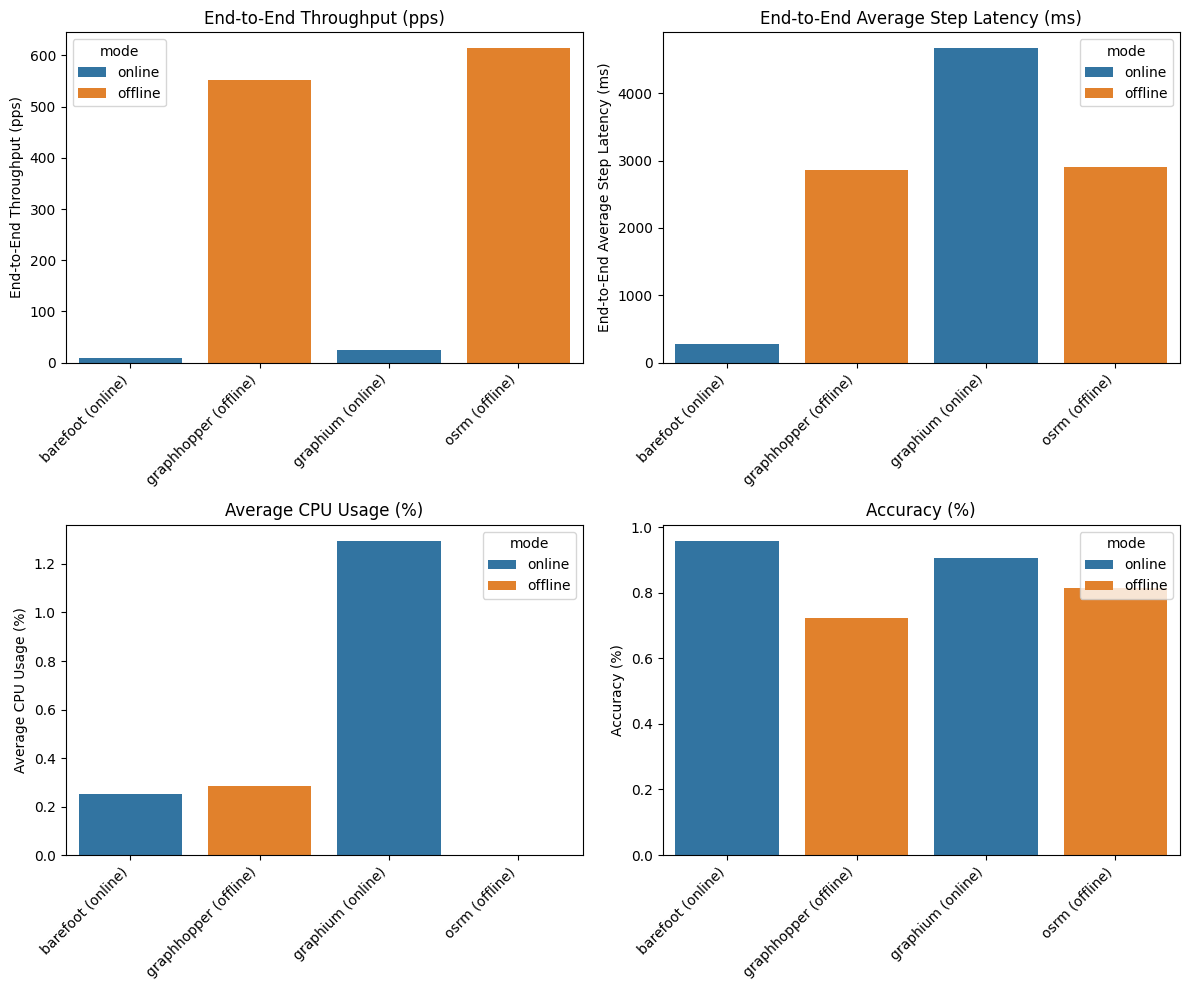

In [14]:
# plot final_runs_df_agg using seaborn
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs = axs.flatten()
metrics = [
    "e2e_throughput_pps",
    "e2e_avg_step_latency_ms",
    "cpu_avg",
    "accuracy",
]
titles = [
    "End-to-End Throughput (pps)",
    "End-to-End Average Step Latency (ms)",
    "Average CPU Usage (%)",
    "Accuracy (%)",
]

for i, metric in enumerate(metrics):
    final_runs_df_agg['label'] = final_runs_df_agg['matcher_name'] + ' (' + final_runs_df_agg['mode'] + ')'
    sns.barplot(data=final_runs_df_agg, x='label', y=metric, hue='mode', ax=axs[i])
    axs[i].set_title(titles[i])
    axs[i].set_ylabel(titles[i])
    axs[i].set_xlabel('')
    axs[i].tick_params(axis='x', rotation=45)
    plt.setp(axs[i].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()


   matcher_name  sample_rate   f1_mean  error_rate_mean  nk_error_mean  runs
0      barefoot          1.0  0.962462         0.037538       0.077555    20
1      barefoot          5.0  0.988539         0.011461       0.022625    20
2      barefoot         10.0  0.985045         0.014955       0.029302    20
3      barefoot         20.0  0.976424         0.023576       0.045261    20
4   graphhopper          1.0  0.786160         0.213840       0.488753    60
5   graphhopper          5.0  0.864142         0.135858       0.283907    60
6   graphhopper         10.0  0.838023         0.161977       0.314321    60
7   graphhopper         20.0  0.771570         0.228430       0.434299    60
8      graphium          1.0  0.930768         0.069232       0.138932    59
9      graphium          5.0  0.937322         0.062678       0.121365    60
10     graphium         10.0  0.962715         0.037285       0.069206    60
11     graphium         20.0  0.956563         0.043437       0.079846    60

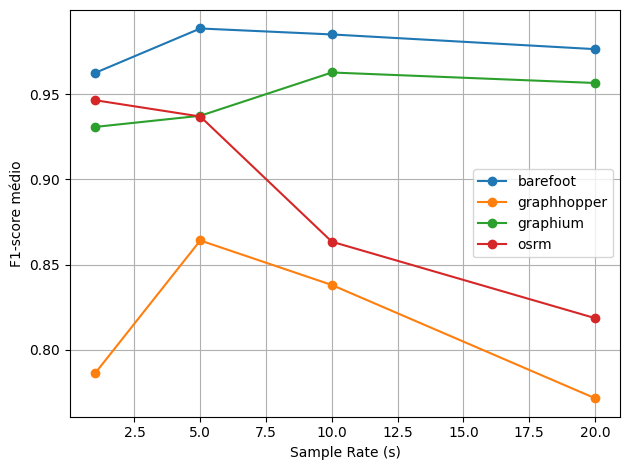

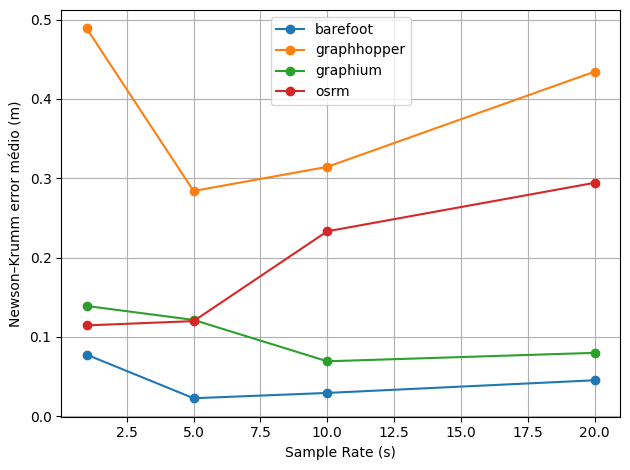

In [39]:
# --------------------------------------------------
# Load data
# --------------------------------------------------
df = read_csv(final_path)

# --------------------------------------------------
# Extract sample rate from dataset_id_prom
# Example: ohare_filtered_vid_1139_sr_5.0 -> 5.0
# --------------------------------------------------
df = add_sample_rate(df, "dataset_id_prom")

# Sanity check
df = df.dropna(subset=["sample_rate"])

# --------------------------------------------------
# Aggregate metrics for QP1
# --------------------------------------------------
qp1_agg = (
    df.groupby(["matcher_name", "sample_rate"], as_index=False)
    .agg(
        f1_mean=("f1_score", "mean"),
        error_rate_mean=("error_rate", "mean"),
        nk_error_mean=("newson_krumm_error", "mean"),
        runs=("f1_score", "count"),
    )
    .sort_values(["matcher_name", "sample_rate"])
)

print(qp1_agg)

# --------------------------------------------------
# Plot 1: F1-score vs sample rate
# --------------------------------------------------
plot_line_by_group(
    qp1_agg,
    x="sample_rate",
    y="f1_mean",
    group="matcher_name",
    xlabel="Sample Rate (s)",
    ylabel="F1-score médio",
    file_name="qp1_f1_vs_sample_rate.pdf",
    order=ORDER,
)
# --------------------------------------------------
# Plot 2: Newson–Krumm error vs sample rate
# --------------------------------------------------
plot_line_by_group(
    qp1_agg,
    x="sample_rate",
    y="nk_error_mean",
    group="matcher_name",
    xlabel="Sample Rate (s)",
    ylabel="Newson–Krumm error médio (m)",
    file_name="qp1_nk_error_vs_sample_rate.pdf",
    order=ORDER,
)


## QP2


   matcher_name  sample_rate  latency_mean_ms  runs
0      barefoot          1.0        34.537087    20
1      barefoot          5.0       164.426410    20
2      barefoot         10.0       320.627659    20
3      barefoot         20.0       613.797522    20
4   graphhopper          1.0       504.643507    60
5   graphhopper          5.0      2100.998934    60
6   graphhopper         10.0      3483.444056    60
7   graphhopper         20.0      5327.091465    60
8      graphium          1.0       434.446059    59
9      graphium          5.0      2830.137990    60
10     graphium         10.0      6351.712791    60
11     graphium         20.0      8997.621100    60
12         osrm          1.0       545.608316    51
13         osrm          5.0      2061.520280    60
14         osrm         10.0      3427.270846    60
15         osrm         20.0      5252.815322    60


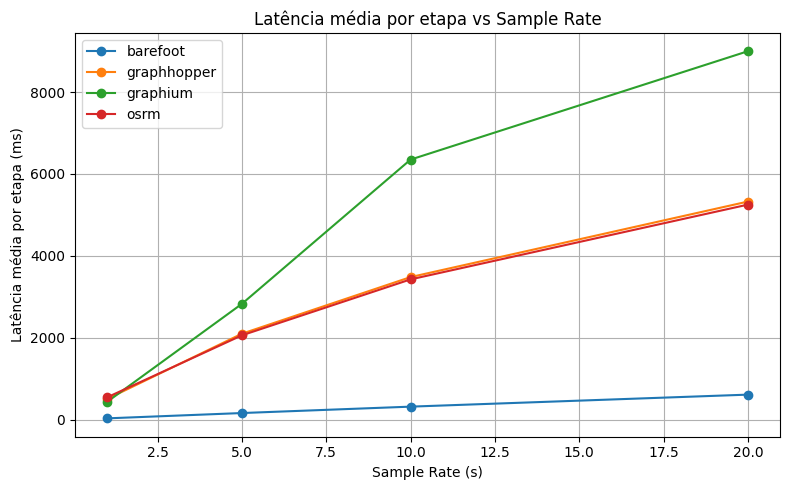

In [40]:
# --------------------------------------------------
# Load data
# --------------------------------------------------
df = read_csv(final_path)

# --------------------------------------------------
# Extract sample rate from dataset_id_prom
# Example: ohare_filtered_vid_1139_sr_5.0 -> 5.0
# --------------------------------------------------
df = add_sample_rate(df, "dataset_id_prom")
df = df.dropna(subset=["sample_rate"])

# --------------------------------------------------
# QP2: Temporal efficiency (latency) vs sample rate
# Choose one latency metric to be consistent.
# Recommended: e2e_avg_step_latency_ms (average step latency in ms)
# --------------------------------------------------
lat_col = "e2e_avg_step_latency_ms"

# Keep only rows with latency available (some rows may be missing, e.g., failed runs)
df_lat = df.dropna(subset=[lat_col]).copy()

qp2_agg = (
    df_lat.groupby(["matcher_name", "sample_rate"], as_index=False)
    .agg(
        latency_mean_ms=(lat_col, "mean"),
        runs=(lat_col, "count"),
    )
    .sort_values(["matcher_name", "sample_rate"])
)

print(qp2_agg)


plot_line_by_group(
    qp2_agg,
    x="sample_rate",
    y="latency_mean_ms",
    group="matcher_name",
    xlabel="Sample Rate (s)",
    ylabel="Latência média por etapa (ms)",
    title="Latência média por etapa vs Sample Rate",
    figsize=(8, 5),
    order=ORDER,
    colors=COLOR,
    file_name="qp2_latency_vs_sample_rate.pdf",
)


    matcher_variant  sample_rate  latency_mean_ms  steps  runs
0          barefoot          1.0        34.617042   5269    20
1          barefoot          5.0       165.085977   1072    20
2          barefoot         10.0       323.018834    548    20
3          barefoot         20.0       622.040391    282    20
4       graphhopper          1.0       315.497543   1792    60
5       graphhopper          5.0      1394.585863    387    60
6       graphhopper         10.0      2495.684464    216    60
7       graphhopper         20.0      4194.818088    127    60
8   graphium (cold)          1.0       268.713297   2097    59
9   graphium (cold)          5.0      1977.633275    276    60
10  graphium (cold)         10.0      5807.307656     94    60
11  graphium (cold)         20.0      8997.621100     60    60
12  graphium (warm)          1.0       243.296723   2038    59
13  graphium (warm)          5.0      1329.032961    228    60
14  graphium (warm)         10.0      4384.956796     7

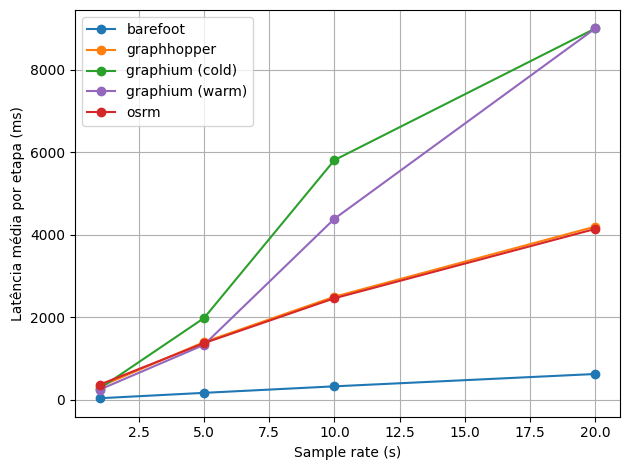

    matcher_variant  batch_size_mm  latency_mean_ms  steps  runs
0       graphhopper            5.0       492.587831   1481    80
1       graphhopper           10.0       954.260315    760    80
2       graphhopper           30.0      2569.842172    281    80
3   graphium (cold)            5.0       514.753779   1415    79
4   graphium (cold)           10.0      1011.400846    726    80
5   graphium (cold)           30.0      1897.433011    386    80
6   graphium (warm)            5.0       398.059331   1372    79
7   graphium (warm)           10.0       807.384684    682    80
8   graphium (warm)           30.0      1604.937782    342    80
9              osrm            5.0       665.148972    928    71
10             osrm           10.0       935.725211    760    80
11             osrm           30.0      2526.910941    281    80


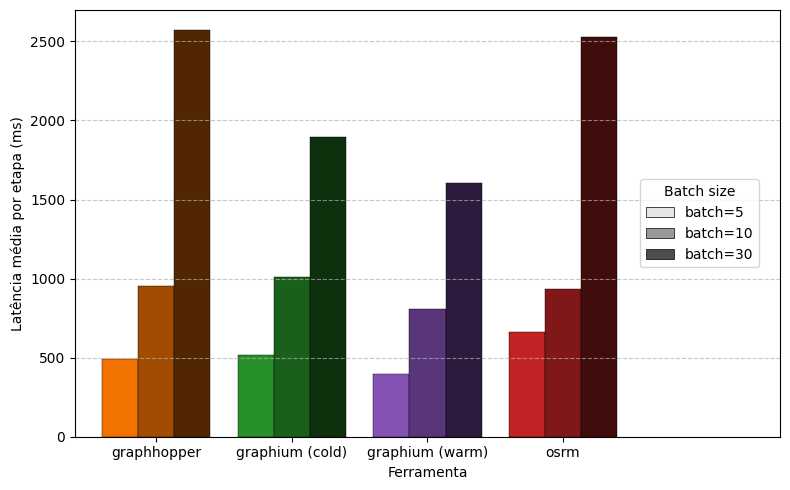

In [41]:
# --------------------------------------------------
# Load datasets
# --------------------------------------------------
final_df = read_csv(final_path)
e2e_df = read_csv(e2e_path)

# --------------------------------------------------
# Extract sample rate from dataset_id_mm (preferred) or dataset_id_prom fallback
# --------------------------------------------------
if "dataset_id_mm" in final_df.columns:
    final_df = add_sample_rate(final_df, "dataset_id_mm")
else:
    final_df = add_sample_rate(final_df, "dataset_id_prom")

# --------------------------------------------------
# Join E2E steps with run-level metadata
# --------------------------------------------------
meta_cols = ["run_id", "matcher_name_mm", "sample_rate"]
for c in ["batch_size_mm", "dataset_id_mm"]:
    if c in final_df.columns:
        meta_cols.append(c)

df = e2e_df.merge(final_df[meta_cols], on="run_id", how="left")

# Keep only rows we can analyze
df = df.dropna(subset=["matcher_name", "sample_rate", "step_latency_ms"]).copy()

# Ensure numeric
df["sample_rate"] = df["sample_rate"].astype(float)

# --------------------------------------------------
# Build matcher_variant with Graphium cold/warm
# Warm rule:
# - For runs with >1 step: drop step_index == 0
# - For runs with exactly 1 step: keep step_index == 0 (so warm exists)
# --------------------------------------------------
non_graph = df[df["matcher_name"] != "graphium"].copy()
non_graph["matcher_variant"] = non_graph["matcher_name"]

graph = df[df["matcher_name"] == "graphium"].copy()

# Cold = all steps
graph_cold = graph.copy()
graph_cold["matcher_variant"] = "graphium (cold)"

# Determine runs that have only 1 step
# (step_count == 1) OR (max step_index == 0) – both are safe checks
graph_run_steps = (
    graph.groupby("run_id", as_index=False)
    .agg(step_count=("step_index", "count"), max_step=("step_index", "max"))
)
graph = graph.merge(graph_run_steps, on="run_id", how="left")

# Warm selection:
# - if run has only 1 step (max_step == 0 or step_count == 1): keep it
# - else: exclude step 0
warm_mask = (graph["step_count"] == 1) | (graph["max_step"] == 0) | (graph["step_index"] != 0)
graph_warm = graph[warm_mask].copy()
graph_warm["matcher_variant"] = "graphium (warm)"

# Combine dataset for analysis
df_all = pd.concat([non_graph, graph_cold, graph_warm], ignore_index=True)

# --------------------------------------------------
# Fixed colors as requested
# --------------------------------------------------
color = {
    "barefoot": "tab:blue",
    "graphhopper": "tab:orange",
    "graphium (cold)": "tab:green",
    "graphium (warm)": "tab:purple",
    "osrm": "tab:red",
}

# Optional: enforce consistent plotting order
PLOT_ORDER = ["barefoot", "graphhopper", "graphium (cold)", "graphium (warm)", "osrm"]

# --------------------------------------------------
# QP2 aggregation: latency vs sample_rate
# --------------------------------------------------
qp2_sr = (
    df_all.groupby(["matcher_variant", "sample_rate"], as_index=False)
    .agg(
        latency_mean_ms=("step_latency_ms", "mean"),
        steps=("step_latency_ms", "count"),
        runs=("run_id", pd.Series.nunique),
    )
    .sort_values(["matcher_variant", "sample_rate"])
)

print(qp2_sr)

# Plot: latency mean vs sample rate

plot_line_by_group(
    qp2_sr,
    x="sample_rate",
    y="latency_mean_ms",
    group="matcher_variant",
    xlabel="Sample rate (s)",
    ylabel="Latência média por etapa (ms)",
    # title="QP2 — Latência média vs taxa de amostragem (Graphium: cold vs warm)",
    order=PLOT_ORDER,
    colors=color,
    file_name="qp2_latency_vs_sample_rate.pdf",
)

# --------------------------------------------------
# QP2 aggregation: latency vs batch_size (if available)
# --------------------------------------------------
batch_col = "batch_size_mm" if "batch_size_mm" in df_all.columns else None

if batch_col:
    df_b = df_all.dropna(subset=[batch_col]).copy()
    df_b[batch_col] = pd.to_numeric(df_b[batch_col], errors="coerce")
    df_b = df_b.dropna(subset=[batch_col])

    qp2_bs = (
        df_b.groupby(["matcher_variant", batch_col], as_index=False)
        .agg(
            latency_mean_ms=("step_latency_ms", "mean"),
            steps=("step_latency_ms", "count"),
            runs=("run_id", pd.Series.nunique),
        )
        .sort_values(["matcher_variant", batch_col])
    )

    print(qp2_bs)

    plot_grouped_bars_by_batch(
        qp2_bs,
        value_col="latency_mean_ms",
        ylabel="Latência média por etapa (ms)",
        matcher_name_col="matcher_variant",
        # title="QP2 — Latência média vs tamanho do lote (batch size)",
        file_name="qp2_latency_vs_batch_size.pdf",
        color=color,
        order=[o for o in PLOT_ORDER if o != "barefoot"],
    )
else:
    print("batch_size_mm não encontrado no metadata; pulei o gráfico por batch size.")


Usando coluna de tempo total: duration_s
   matcher_name_mm  sample_rate  e2e_time_mean_s  runs
0         barefoot          1.0        12.750000    20
1         barefoot          5.0        12.350000    20
2         barefoot         10.0        12.100000    20
3         barefoot         20.0        12.100000    20
4      graphhopper          1.0        17.916667    60
5      graphhopper          5.0        17.600000    60
6      graphhopper         10.0        17.583333    60
7      graphhopper         20.0        17.416667    60
8         graphium          1.0        19.627119    59
9         graphium          5.0        19.033333    60
10        graphium         10.0        19.116667    60
11        graphium         20.0        18.966667    60
12            osrm          1.0        12.254902    51
13            osrm          5.0        12.350000    60
14            osrm         10.0        12.333333    60
15            osrm         20.0        12.100000    60


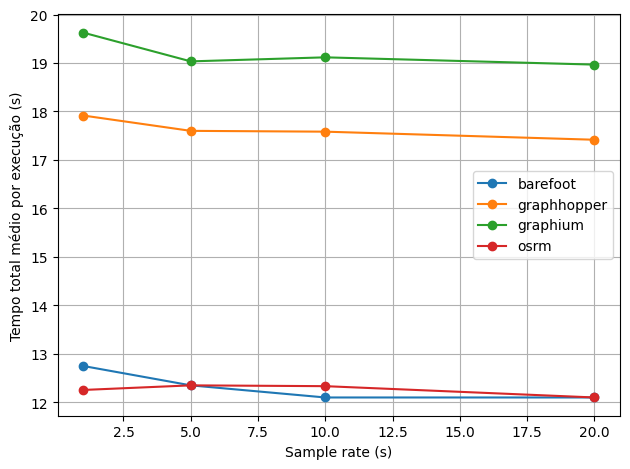

In [43]:
# Escolha a coluna de tempo total disponível
e2e_time_col = "duration_s"
print(f"Usando coluna de tempo total: {e2e_time_col}")

qp2_e2e = (
    final_df.dropna(subset=["matcher_name_mm", "sample_rate", e2e_time_col])
    .groupby(["matcher_name_mm", "sample_rate"], as_index=False)
    .agg(
        e2e_time_mean_s=(e2e_time_col, "mean"),
        runs=(e2e_time_col, "count"),
    )
    .sort_values(["matcher_name_mm", "sample_rate"])
)

print(qp2_e2e)

# Ajuste nomes pra bater com o seu padrão (matcher_name_mm -> matcher_name)
qp2_e2e = qp2_e2e.rename(columns={"matcher_name_mm": "matcher_name"})
qp2_e2e["matcher_variant"] = qp2_e2e["matcher_name"]  # sem warm/cold aqui

plot_line_by_group(
    qp2_e2e,
    x="sample_rate",
    y="e2e_time_mean_s",
    group="matcher_variant",
    xlabel="Sample rate (s)",
    ylabel="Tempo total médio por execução (s)",
    order=["barefoot", "graphhopper", "graphium", "osrm"],
    colors={
        "barefoot": "tab:blue",
        "graphhopper": "tab:orange",
        "graphium": "tab:green",
        "osrm": "tab:red",
    },
    file_name="qp2_e2e_time_vs_sample_rate.pdf",
)


## QP3


   matcher_name  sample_rate   f1_mean  err_rate_mean  nk_err_mean  \
0      barefoot          1.0  0.962462       0.037538     0.077555   
1      barefoot          5.0  0.988539       0.011461     0.022625   
2      barefoot         10.0  0.985045       0.014955     0.029302   
3      barefoot         20.0  0.976424       0.023576     0.045261   
4   graphhopper          1.0  0.786160       0.213840     0.488753   
5   graphhopper          5.0  0.864142       0.135858     0.283907   
6   graphhopper         10.0  0.838023       0.161977     0.314321   
7   graphhopper         20.0  0.771570       0.228430     0.434299   
8      graphium          1.0  0.930768       0.069232     0.138932   
9      graphium          5.0  0.937322       0.062678     0.121365   
10     graphium         10.0  0.962715       0.037285     0.069206   
11     graphium         20.0  0.956563       0.043437     0.079846   
12         osrm          1.0  0.946465       0.053535     0.114462   
13         osrm     

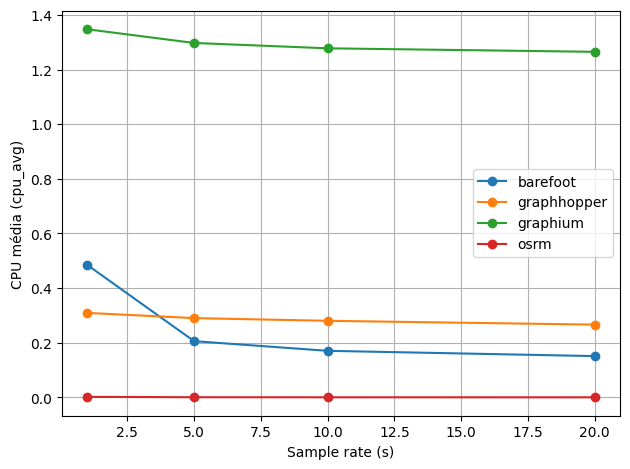

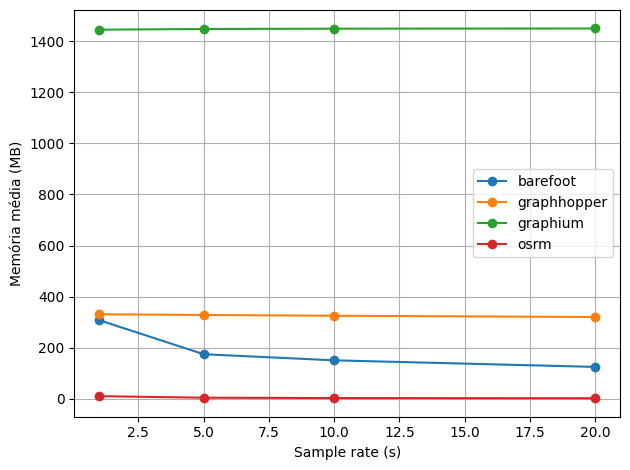

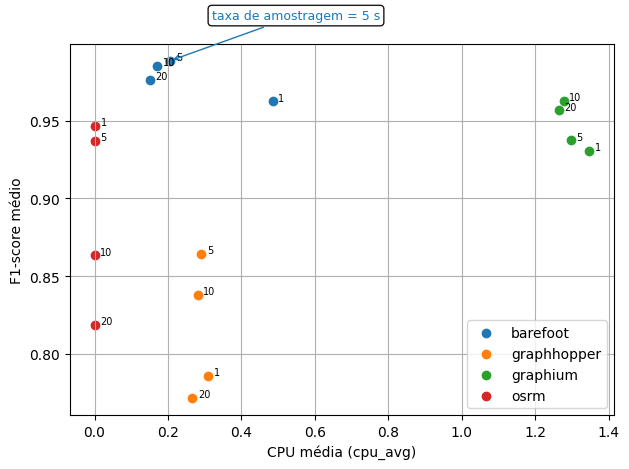

In [ ]:
# --------------------------------------------------
# Preparar dados (run-level)
# --------------------------------------------------
df = final_df.copy()

# sample_rate (preferir dataset_id_mm)
if "dataset_id_mm" in df.columns:
    df["sample_rate"] = df["dataset_id_mm"].apply(extract_sample_rate)
else:
    df["sample_rate"] = df["dataset_id_prom"].apply(extract_sample_rate)

df = df.dropna(subset=["sample_rate", "matcher_name"])
df["sample_rate"] = df["sample_rate"].astype(float)

# Se quiser focar só no online, descomenta:
# df = df[df["mode"].eq("online")].copy()

# --------------------------------------------------
# Agregação QP3: custo + qualidade por ferramenta × sample_rate
# --------------------------------------------------
qp3 = (
    df.groupby(["matcher_name", "sample_rate"], as_index=False)
      .agg(
          # Qualidade
          f1_mean=("f1_score", "mean"),
          err_rate_mean=("error_rate", "mean"),
          nk_err_mean=("newson_krumm_error", "mean"),

          # Custo
          cpu_avg_mean=("cpu_avg", "mean"),
          mem_avg_mean=("mem_avg_mb", "mean"),

          # Opcional (se você quiser)
          cpu_total_core_s_mean=("cpu_total_core_s", "mean"),
          mem_peak_mean=("mem_peak_mb", "mean"),

          runs=("run_id", "count"),
      )
      .sort_values(["matcher_name", "sample_rate"])
)

print(qp3)

# --------------------------------------------------
# (Opcional, mas útil) métricas simples de "custo por qualidade"
# sem inventar muita coisa:
# --------------------------------------------------
eps = 1e-9
qp3["cpu_per_f1"] = qp3["cpu_avg_mean"] / (qp3["f1_mean"] + eps)
qp3["mem_per_f1"] = qp3["mem_avg_mean"] / (qp3["f1_mean"] + eps)

# --------------------------------------------------
# Cores fixas (no seu padrão)
# --------------------------------------------------
color = {
    "barefoot": "tab:blue",
    "graphhopper": "tab:orange", 
    "graphium": "tab:green",
    "osrm": "tab:red",
}
order = ["barefoot", "graphhopper", "graphium", "osrm"]

# --------------------------------------------------
# Plot 1: CPU avg vs sample_rate (linhas)
# --------------------------------------------------
plt.figure()
for name in order:
    g = qp3[qp3["matcher_name"] == name]
    if g.empty:
        continue
    plt.plot(g["sample_rate"], g["cpu_avg_mean"], marker="o", label=name, color=color.get(name))

plt.xlabel("Sample rate (s)")
plt.ylabel("CPU média (cpu_avg)")
# plt.title("QP3 — Custo computacional: CPU média vs taxa de amostragem")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("qp3_cpu_vs_sample_rate.pdf")
plt.show()

# --------------------------------------------------
# Plot 2: Mem avg vs sample_rate (linhas)
# --------------------------------------------------
plt.figure()
for name in order:
    g = qp3[qp3["matcher_name"] == name]
    if g.empty:
        continue
    plt.plot(g["sample_rate"], g["mem_avg_mean"], marker="o", label=name, color=color.get(name))

plt.xlabel("Sample rate (s)")
plt.ylabel("Memória média (MB)")
# plt.title("QP3 — Custo computacional: Memória média vs taxa de amostragem")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("qp3_mem_vs_sample_rate.pdf")
plt.show()

# --------------------------------------------------
# Plot 3 (opcional, mas MUITO bom e simples): Qualidade vs CPU (trade-off)
# (cada ponto = uma taxa de amostragem)
# --------------------------------------------------
plt.figure()
annotated_special = False
for name in order:
    g = qp3[qp3["matcher_name"] == name]
    if g.empty:
        continue
    plt.scatter(g["cpu_avg_mean"], g["f1_mean"], label=name, color=color.get(name))
    # anotação com sample_rate (pouco texto)
    for _, row in g.iterrows():
        plt.annotate(f"{int(row['sample_rate'])}", (row["cpu_avg_mean"], row["f1_mean"]), fontsize=7, xytext=(4, 0.5), textcoords='offset points')
        # nota com seta saindo de um dos números (para sample_rate alvo)
        if (not annotated_special) and ("target_sr" in globals()) and (row["sample_rate"] == target_sr):
            plt.annotate(
                f"taxa de amostragem = {int(row['sample_rate'])} s",
                xy=(row["cpu_avg_mean"], row["f1_mean"]),
                xytext=(30, 30),
                textcoords="offset points",
                arrowprops=dict(arrowstyle="->", color=color.get(name)),
                bbox=dict(boxstyle="round,pad=0.3", fc="w", alpha=0.9),
                fontsize=9,
                color=color.get(name),
            )
            annotated_special = True
# salvar como svg
plt.xlabel("CPU média (cpu_avg)")
plt.ylabel("F1-score médio")
# plt.title("QP3 — Trade-off: qualidade (F1) vs custo (CPU)\n(anotações = sample rate)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("qp3_tradeoff_quality_cpu.svg")
plt.savefig("qp3_tradeoff_quality_cpu.pdf")
plt.show()


## QP4


   matcher_name  sample_rate  throughput_pps_mean  throughput_pps_p50  \
0      barefoot          1.0            19.945986           20.675824   
1      barefoot          5.0             4.189147            4.375000   
2      barefoot         10.0             2.194167            2.303846   
3      barefoot         20.0             1.139323            1.154762   
4   graphhopper          1.0            14.112535           15.085139   
5   graphhopper          5.0             2.928427            3.114379   
6   graphhopper         10.0             1.501456            1.583591   
7   graphhopper         20.0             0.783700            0.823529   
8      graphium          1.0            12.880293           13.600000   
9      graphium          5.0             2.710492            2.894444   
10     graphium         10.0             1.381021            1.435526   
11     graphium         20.0             0.719248            0.750000   
12         osrm          1.0            20.190793  

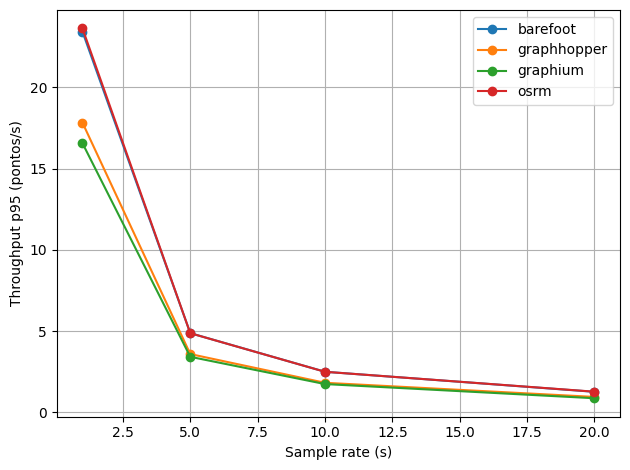

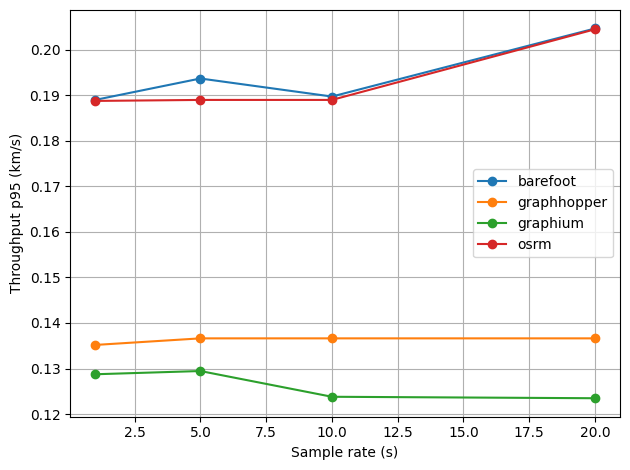

In [44]:

# -----------------------------
# Cores base por ferramenta
# -----------------------------
color = {
    "barefoot": "tab:blue",
    "graphhopper": "tab:orange",
    "graphium": "tab:green",
    "osrm": "tab:red",
}
order = ["barefoot", "graphhopper", "graphium", "osrm"]


# helper for p95
def _pct95(s):
    return np.percentile(s, 95)


# -----------------------------
# 1) sample_rate no final_runs_df
# -----------------------------
final_df = final_runs_df.copy()

if "dataset_id_mm" in final_df.columns:
    final_df["sample_rate"] = final_df["dataset_id_mm"].apply(extract_sample_rate)
else:
    final_df["sample_rate"] = final_df["dataset_id_prom"].apply(extract_sample_rate)

final_df = final_df.dropna(
    subset=["run_id", "matcher_name", "sample_rate", "duration_s"]
).copy()
final_df["sample_rate"] = final_df["sample_rate"].astype(float)
final_df["duration_s"] = pd.to_numeric(final_df["duration_s"], errors="coerce")
final_df = final_df.dropna(subset=["duration_s"])
final_df = final_df[final_df["duration_s"] > 0]

# -----------------------------
# 2) total de pontos por run via e2e_df (max cum_points)
# -----------------------------
e2e_pts = e2e_df.copy()
e2e_pts["cum_points"] = pd.to_numeric(e2e_pts["cum_points"], errors="coerce")
e2e_pts = e2e_pts.dropna(subset=["run_id", "cum_points"])

points_per_run = e2e_pts.groupby("run_id", as_index=False).agg(
    total_points=("cum_points", "max")
)

# -----------------------------
# 3) comprimento da trajetória (pra km/s)
#    Preferir total_gt_length (geralmente em metros); fallback para total_added_length
# -----------------------------
if "total_gt_length" in final_df.columns:
    length_col = "total_gt_length"
elif "total_added_length" in final_df.columns:
    length_col = "total_added_length"
else:
    length_col = None  # sem km/s

if length_col:
    final_df[length_col] = pd.to_numeric(final_df[length_col], errors="coerce")

# -----------------------------
# 4) Merge final_runs_df + total_points
# -----------------------------
df = final_df.merge(points_per_run, on="run_id", how="left")

# Se algum run não tiver steps no e2e_df, cai fora (ou você pode preencher com 0)
df = df.dropna(subset=["total_points"]).copy()
df["total_points"] = pd.to_numeric(df["total_points"], errors="coerce")
df = df.dropna(subset=["total_points"])
df = df[df["total_points"] > 0]

# -----------------------------
# 5) Throughput calculado
# -----------------------------
df["throughput_pps_calc"] = df["total_points"] / df["duration_s"]

if length_col:
    # assumindo metros -> km
    df["throughput_kmps_calc"] = (df[length_col] / 1000.0) / df["duration_s"]

# -----------------------------
# 6) Agregar por ferramenta × sample_rate (inclui p50 e p95)
# -----------------------------
agg_cols = {
    "throughput_pps_mean": ("throughput_pps_calc", "mean"),
    "throughput_pps_p50": ("throughput_pps_calc", "median"),
    "throughput_pps_p95": ("throughput_pps_calc", _pct95),
    "runs": ("run_id", "count"),
}
if length_col:
    agg_cols["throughput_kmps_mean"] = ("throughput_kmps_calc", "mean")
    agg_cols["throughput_kmps_p50"] = ("throughput_kmps_calc", "median")
    agg_cols["throughput_kmps_p95"] = ("throughput_kmps_calc", _pct95)

qp4_calc = (
    df.groupby(["matcher_name", "sample_rate"], as_index=False)
    .agg(**agg_cols)
    .sort_values(["matcher_name", "sample_rate"])
)

print(qp4_calc)

# -----------------------------
# 7) Plot: barras por sample_rate (pps)
# -----------------------------
plot_line_by_group(
    qp4_calc,
    x="sample_rate",
    y="throughput_pps_p95",
    group="matcher_name",
    xlabel="Sample rate (s)",
    ylabel="Throughput p95 (pontos/s)",
    # title="QP4 — Vazão p95 (pontos/s) por ferramenta, com variação de sample rate",
    file_name="qp4_throughput_pps_by_sample_rate.pdf",
    colors=color,
    order=order,
)

# -----------------------------
# 8) Plot: barras por sample_rate (km/s), se houver length
# -----------------------------
if length_col:
    plot_line_by_group(
        qp4_calc,
        x="sample_rate",
        y="throughput_kmps_p95",
        group="matcher_name",
        xlabel="Sample rate (s)",
        ylabel="Throughput p95 (km/s)",
        # title="QP4 — Vazão p95 (km/s) por ferramenta, com variação de sample rate",
        file_name="qp4_throughput_kmps_by_sample_rate.pdf",
        colors=color,
        order=order,
    )
else:
    print("Sem coluna de comprimento (total_gt_length/total_added_length). Pulei km/s.")


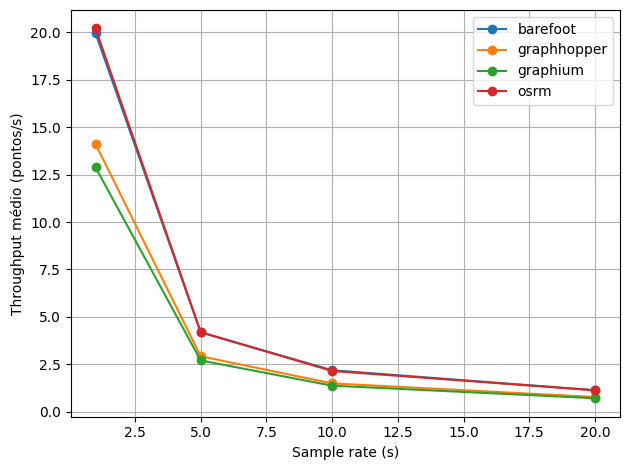

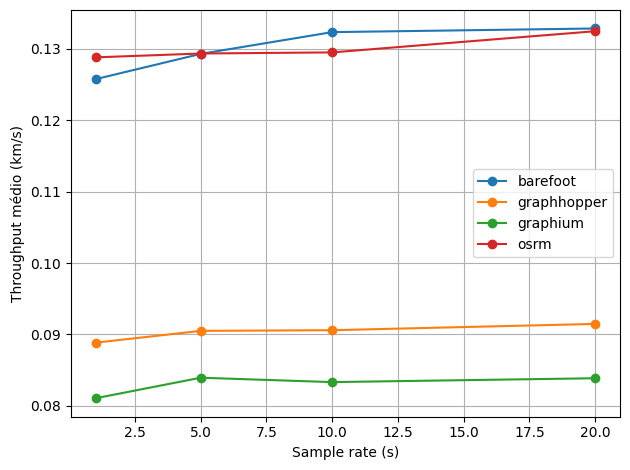

In [42]:

# Espera-se que você já tenha calculado `qp4_calc` na célula anterior
# com colunas:
# - matcher_name
# - sample_rate
# - throughput_pps_mean
# - (opcional) throughput_kmps_mean

color = {
    "barefoot": "tab:blue",
    "graphhopper": "tab:orange",
    "graphium": "tab:green",
    "osrm": "tab:red",
}
order = ["barefoot", "graphhopper", "graphium", "osrm"]

# -----------------------------
# Line plot: throughput (pps) vs sample_rate
# -----------------------------
plt.figure()
for name in order:
    g = qp4_calc[qp4_calc["matcher_name"] == name].sort_values("sample_rate")
    if g.empty:
        continue
    plt.plot(
        g["sample_rate"],
        g["throughput_pps_mean"],
        marker="o",
        label=name,
        color=color.get(name),
    )

plt.xlabel("Sample rate (s)")
plt.ylabel("Throughput médio (pontos/s)")
# plt.title("QP4 — Vazão média (pontos/s) vs taxa de amostragem")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("qp4_throughput_pps_vs_sample_rate.pdf")
plt.show()

# -----------------------------
# Line plot: throughput (km/s) vs sample_rate (se existir)
# -----------------------------
if "throughput_kmps_mean" in qp4_calc.columns:
    plt.figure()
    for name in order:
        g = qp4_calc[qp4_calc["matcher_name"] == name].sort_values("sample_rate")
        if g.empty:
            continue
        plt.plot(
            g["sample_rate"],
            g["throughput_kmps_mean"],
            marker="o",
            label=name,
            color=color.get(name),
        )

    plt.xlabel("Sample rate (s)")
    plt.ylabel("Throughput médio (km/s)")
    # plt.title("QP4 — Vazão média (km/s) vs taxa de amostragem")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("qp4_throughput_kmps_vs_sample_rate.pdf")
    plt.show()
else:
    print("Coluna 'throughput_kmps_mean' não encontrada em qp4_calc; pulei o gráfico km/s.")


  matcher_name  batch_size_mm  throughput_pps_mean  throughput_pps_p95  runs  \
0  graphhopper            5.0             4.798733           16.402727    80   
1  graphhopper           10.0             4.839558           16.402727    80   
2  graphhopper           30.0             4.856298           16.774405    80   
3     graphium            5.0             4.276185           15.262879    79   
4     graphium           10.0             4.426264           14.942803    80   
5     graphium           30.0             4.458290           15.633929    80   
6         osrm            5.0             5.138562           21.086538    71   
7         osrm           10.0             6.937533           22.340196    80   
8         osrm           30.0             6.992473           22.662500    80   

   throughput_kmps_mean  
0              0.090005  
1              0.090759  
2              0.090314  
3              0.082713  
4              0.083055  
5              0.083436  
6              0.

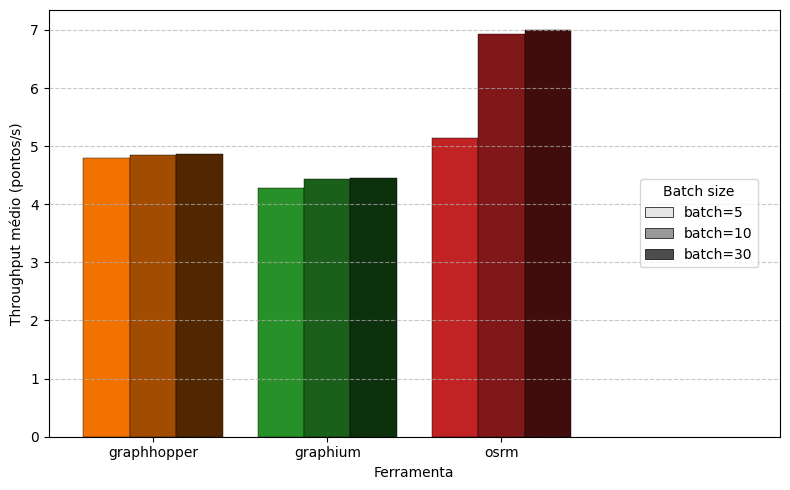

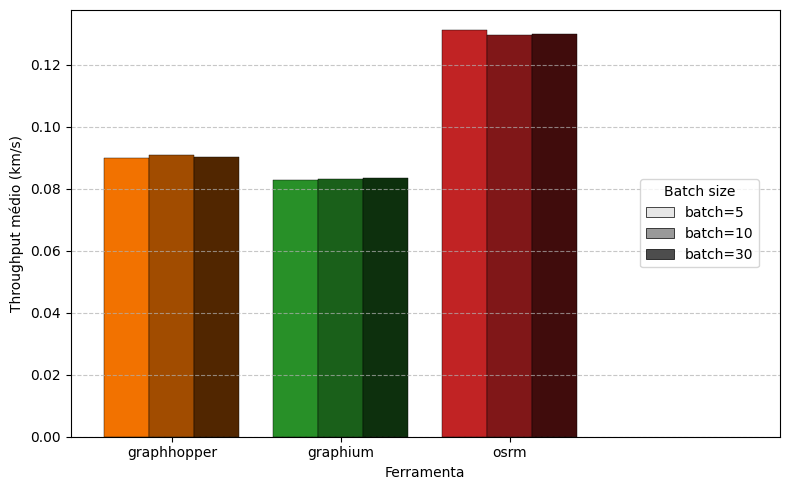

In [ ]:
# Reaproveita as cores por ferramenta
color = {
    "barefoot": "tab:blue",
    "graphhopper": "tab:orange",
    "graphium": "tab:green",
    "osrm": "tab:red",
}
order = [ "graphhopper", "graphium", "osrm"]


# --------------------------------------------------
# 1) Construir dataset run-level com throughput calculado (pps e km/s)
#    (reaproveita df calculado antes, ou recalcula aqui de forma segura)
# --------------------------------------------------

# Detecta colunas
batch_col = "batch_size_mm" if "batch_size_mm" in final_runs_df.columns else "batch_size_prom"
length_col = "total_gt_length" if "total_gt_length" in final_runs_df.columns else (
    "total_added_length" if "total_added_length" in final_runs_df.columns else None
)

# total_points por run via e2e_df (max cum_points)
e2e_pts = e2e_df.copy()
e2e_pts["cum_points"] = pd.to_numeric(e2e_pts["cum_points"], errors="coerce")
e2e_pts = e2e_pts.dropna(subset=["run_id", "cum_points"])
points_per_run = e2e_pts.groupby("run_id", as_index=False).agg(total_points=("cum_points", "max"))

# base df (final runs)
df = final_runs_df.copy()
df["duration_s"] = pd.to_numeric(df["duration_s"], errors="coerce")
df = df.dropna(subset=["run_id", "matcher_name", "duration_s", batch_col])
df = df[df["duration_s"] > 0]

df[batch_col] = pd.to_numeric(df[batch_col], errors="coerce")
df = df.dropna(subset=[batch_col])

if length_col:
    df[length_col] = pd.to_numeric(df[length_col], errors="coerce")

df = df.merge(points_per_run, on="run_id", how="left")
df = df.dropna(subset=["total_points"])
df["total_points"] = pd.to_numeric(df["total_points"], errors="coerce")
df = df[df["total_points"] > 0]

# throughput calculado
df["throughput_pps_calc"] = df["total_points"] / df["duration_s"]
if length_col:
    df["throughput_kmps_calc"] = (df[length_col] / 1000.0) / df["duration_s"]

# --------------------------------------------------
# 2) Agregar por ferramenta × batch_size
# --------------------------------------------------
agg_cols = {
    "throughput_pps_mean": ("throughput_pps_calc", "mean"),
    "throughput_pps_p95": ("throughput_pps_calc", _pct95),
    "runs": ("run_id", "count"),
}
if length_col:
    agg_cols["throughput_kmps_mean"] = ("throughput_kmps_calc", "mean")

qp4_batch = (
    df.groupby(["matcher_name", batch_col], as_index=False)
      .agg(**agg_cols)
      .sort_values(["matcher_name", batch_col])
)

print(qp4_batch)

# --------------------------------------------------
# 3) Plot: barras de throughput (pontos/s) vs batch
# --------------------------------------------------
plot_grouped_bars_by_batch(
    qp4_batch,
    value_col="throughput_pps_mean",
    ylabel="Throughput médio (pontos/s)",
    # title="QP4 — Vazão média (pontos/s) por ferramenta em função do batch size",
    batch_col=batch_col,
    # log_scale=True,
    file_name="qp4_throughput_pps_by_batch.pdf",
    order=order,
    color=color,
)

# --------------------------------------------------
# 4) Plot: barras de throughput (km/s) vs batch (se existir)
# --------------------------------------------------
if "throughput_kmps_mean" in qp4_batch.columns:
    plot_grouped_bars_by_batch(
        qp4_batch,
        value_col="throughput_kmps_mean",
        ylabel="Throughput médio (km/s)",
        # title="QP4 — Vazão média (km/s) por ferramenta em função do batch size",
        batch_col=batch_col,
        log_scale=False,
        file_name="qp4_throughput_kmps_by_batch.pdf",
        order=order,
        color=color,
    )
else:
    print("Sem coluna de comprimento (total_gt_length/total_added_length). Pulei km/s.")
